1. Install Required Libraries
Explanation

This section installs all required Python libraries for the project. These libraries allow us to download financial data, perform machine learning modelling, calculate technical indicators, and optimise model parameters.

In [1]:

!pip install pandas numpy matplotlib seaborn yfinance scikit-learn xgboost optuna ta

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached ta-0.11.0.tar.gz (25 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 3.7 MB/s eta 0:00:01
   -------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.41 requires requests_mock, which is not installed.
conda-repo-cli 1.0.41 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.41 requires nbformat==5.4.0, but you have nbformat 5.7.0 which is incompatible.
conda-repo-cli 1.0.41 requires requests==2.28.1, but you have requests 2.32.5 which is incompatible.
tensorboard 2.9.1 requires protobuf<3.20,>=3.9.2, but you have protobuf 7.34.0 which is incompatible.
tensorflow-intel 2.12.0 requires flatbuffers>=2.0, but you have flatbuffers 1.12 which is incompatible.
tensorflow-intel 2.12.0 requires keras<2.13,>=2.12.0, but you have keras 2.9.0 which is incompatible.
tensorflow-intel 2.12.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.34.0 which is

2. Import Python Libraries
Explanation

In this step we import all the Python libraries needed for data analysis, machine learning, and optimisation. Libraries such as Pandas and NumPy are used for data processing, XGBoost is used for machine learning modelling, and Optuna is used for hyperparameter optimisation.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
import optuna

from ta.volatility import BollingerBands
from ta.momentum import RSIIndicator

3. Define the Investment Universe
Explanation

Here we define the list of Irish-linked companies that will form the investment universe. These companies are traded on or linked to the Irish market through Euronext Dublin. The machine learning model will analyse price behaviour across these assets.

In [9]:
tickers = [
"RYAAY",   # Ryanair
"CRH",     # CRH Plc
"AIBRF",   # AIB Group
"KRYAF",   # Kerry Group
"FLTR",    # Flutter
]

4. Download Historical Market Data
Explanation

This section downloads historical stock price data for the selected companies. The data is retrieved using the Yahoo Finance API and contains daily adjusted closing prices, which reflect stock splits and dividends.

In [10]:
data = yf.download(
tickers,
start="2015-01-01",
progress=False
)

prices = data["Close"]
prices = prices.dropna()

5. Calculate Daily Returns
Explanation

Financial returns measure how much the price of an asset changes from one day to the next. These returns are used to analyse investment performance and to build predictive signals for the machine learning model.

In [11]:
returns = prices.pct_change()

returns = returns.dropna()

6. Feature Engineering
Explanation

Feature engineering creates predictive signals from raw financial data. In this step we compute several common quantitative finance indicators such as market returns, volatility, momentum, and moving averages.

In [12]:
features = pd.DataFrame(index=prices.index)

features["mean_return"] = returns.mean(axis=1)

features["volatility"] = returns.std(axis=1)

features["momentum_5"] = prices.pct_change(5).mean(axis=1)

features["momentum_20"] = prices.pct_change(20).mean(axis=1)

features["moving_avg"] = prices.rolling(20).mean().mean(axis=1)

features = features.dropna()

7. Add Technical Indicators
Explanation

Technical indicators help identify market trends and price momentum. The Relative Strength Index (RSI) measures whether an asset is overbought or oversold, while Bollinger Bands measure price volatility relative to historical averages.

In [13]:
rsi = RSIIndicator(close=prices.mean(axis=1), window=14)

features["rsi"] = rsi.rsi()

bb = BollingerBands(close=prices.mean(axis=1), window=20)

features["bb_high"] = bb.bollinger_hband()

features["bb_low"] = bb.bollinger_lband()

features = features.dropna()

8. Create the Prediction Target
Explanation

The machine learning model needs a target variable to predict. In this case, the model will predict whether the market return will be positive or negative on the following day.

In [14]:
future_return = returns.mean(axis=1).shift(-1)

features["target"] = (future_return > 0).astype(int)

features = features.dropna()

9. Split the Data into Training and Testing Sets
Explanation

To evaluate the model properly, we divide the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its predictive performance.

In [15]:
split = int(len(features)*0.8)

train = features.iloc[:split]
test = features.iloc[split:]

X_train = train.drop("target",axis=1)
y_train = train["target"]

X_test = test.drop("target",axis=1)
y_test = test["target"]

10. Train the Baseline Machine Learning Model
Explanation

We begin with a baseline machine learning model using XGBoost. This model is widely used in financial machine learning because it handles complex nonlinear relationships effectively.

In [16]:
model = XGBClassifier(
n_estimators=100,
max_depth=3,
learning_rate=0.1
)

model.fit(X_train,y_train)

preds = model.predict(X_test)

baseline_accuracy = accuracy_score(y_test,preds)

print("Baseline accuracy:",baseline_accuracy)

Baseline accuracy: 0.49333333333333335


11. Hyperparameter Optimisation with Optuna
Explanation

Hyperparameters control how a machine learning model learns from data. Instead of manually choosing these parameters, we use Optuna to automatically search for the best combination that maximises model performance.

In [17]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators",50,300),

        "max_depth": trial.suggest_int("max_depth",2,10),

        "learning_rate": trial.suggest_float("learning_rate",0.01,0.3),

        "subsample": trial.suggest_float("subsample",0.5,1.0),

        "colsample_bytree": trial.suggest_float("colsample_bytree",0.5,1.0)

    }

    model = XGBClassifier(**params)

    model.fit(X_train,y_train)

    preds = model.predict(X_test)

    return accuracy_score(y_test,preds)

12. Run the Optimisation Process
Explanation

This step runs the optimisation algorithm multiple times to explore different combinations of hyperparameters and identify the best-performing configuration.

In [18]:
study = optuna.create_study(direction="maximize")

study.optimize(objective,n_trials=30)

best_params = study.best_params

print("Best parameters:",best_params)

[I 2026-03-16 10:15:37,109] A new study created in memory with name: no-name-133cfe97-624e-4845-8d82-09a7f9336b1b
[I 2026-03-16 10:15:37,405] Trial 0 finished with value: 0.5733333333333334 and parameters: {'n_estimators': 228, 'max_depth': 3, 'learning_rate': 0.13535869917896073, 'subsample': 0.9416126323375478, 'colsample_bytree': 0.9895829441465239}. Best is trial 0 with value: 0.5733333333333334.
[I 2026-03-16 10:15:37,577] Trial 1 finished with value: 0.56 and parameters: {'n_estimators': 201, 'max_depth': 10, 'learning_rate': 0.2328529243506234, 'subsample': 0.8581103349659658, 'colsample_bytree': 0.9624638383423593}. Best is trial 0 with value: 0.5733333333333334.
[I 2026-03-16 10:15:37,688] Trial 2 finished with value: 0.5466666666666666 and parameters: {'n_estimators': 157, 'max_depth': 10, 'learning_rate': 0.26817629521933245, 'subsample': 0.6679924990146696, 'colsample_bytree': 0.5223584827378822}. Best is trial 0 with value: 0.5733333333333334.
[I 2026-03-16 10:15:37,800] T

[I 2026-03-16 10:15:41,375] Trial 27 finished with value: 0.5333333333333333 and parameters: {'n_estimators': 239, 'max_depth': 6, 'learning_rate': 0.24295006433883512, 'subsample': 0.9553194723194098, 'colsample_bytree': 0.9167617040922382}. Best is trial 0 with value: 0.5733333333333334.
[I 2026-03-16 10:15:41,464] Trial 28 finished with value: 0.52 and parameters: {'n_estimators': 187, 'max_depth': 2, 'learning_rate': 0.18544406747279862, 'subsample': 0.8861667876344725, 'colsample_bytree': 0.8689583644548864}. Best is trial 0 with value: 0.5733333333333334.
[I 2026-03-16 10:15:41,610] Trial 29 finished with value: 0.48 and parameters: {'n_estimators': 209, 'max_depth': 9, 'learning_rate': 0.27730348257245097, 'subsample': 0.6998785200511661, 'colsample_bytree': 0.7923358679599061}. Best is trial 0 with value: 0.5733333333333334.


Best parameters: {'n_estimators': 228, 'max_depth': 3, 'learning_rate': 0.13535869917896073, 'subsample': 0.9416126323375478, 'colsample_bytree': 0.9895829441465239}


13. Train the Final Optimised Model
Explanation

After identifying the optimal hyperparameters, we retrain the machine learning model using these parameters to produce the final predictive model.

In [19]:
best_model = XGBClassifier(**best_params)

best_model.fit(X_train,y_train)

predictions = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test,predictions)

print("Final accuracy:",final_accuracy)

Final accuracy: 0.5733333333333334


14. Generate Strategy Returns
Explanation

Model predictions are translated into a simple trading strategy. If the model predicts a positive return, the strategy takes a position in the market.

In [21]:
strategy_returns = returns.loc[X_test.index].mean(axis=1) * predictions

strategy_returns = strategy_returns.dropna()

15. Calculate the Sharpe Ratio
Explanation

The Sharpe ratio measures risk-adjusted returns and is widely used in portfolio management. It was developed by William F. Sharpe to evaluate investment strategies.

In [22]:
def sharpe_ratio(returns):

    return np.sqrt(252) * returns.mean() / returns.std()

strategy_sharpe = sharpe_ratio(strategy_returns)

print("Strategy Sharpe Ratio:",strategy_sharpe)

Strategy Sharpe Ratio: 0.32990980203564885


16. Portfolio Optimisation
Explanation

In this step we determine the optimal allocation of capital across assets to maximise the Sharpe ratio of the portfolio.

In [23]:
from scipy.optimize import minimize

cov_matrix = returns.cov()

mean_returns = returns.mean()

17. Visualise Strategy Performance
Explanation

Finally, we plot cumulative returns to visualise how the strategy performs over time.

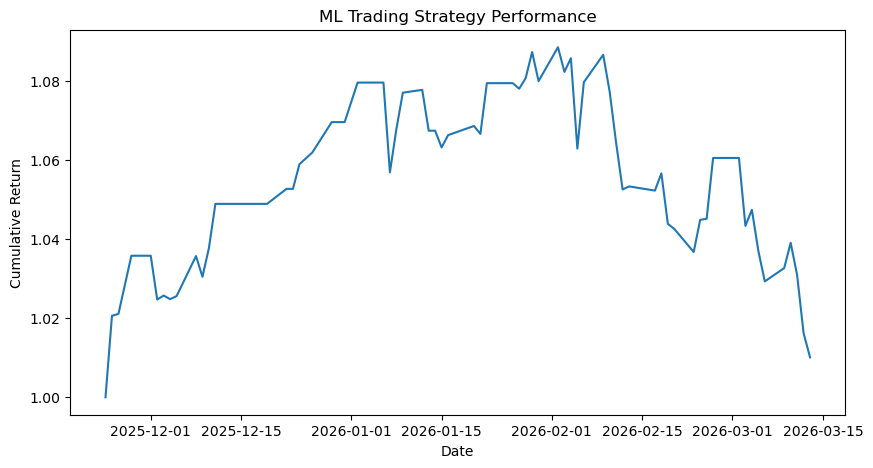

In [24]:
cumulative = (1 + strategy_returns).cumprod()

plt.figure(figsize=(10,5))

plt.plot(cumulative)

plt.title("ML Trading Strategy Performance")

plt.xlabel("Date")

plt.ylabel("Cumulative Return")

plt.show()

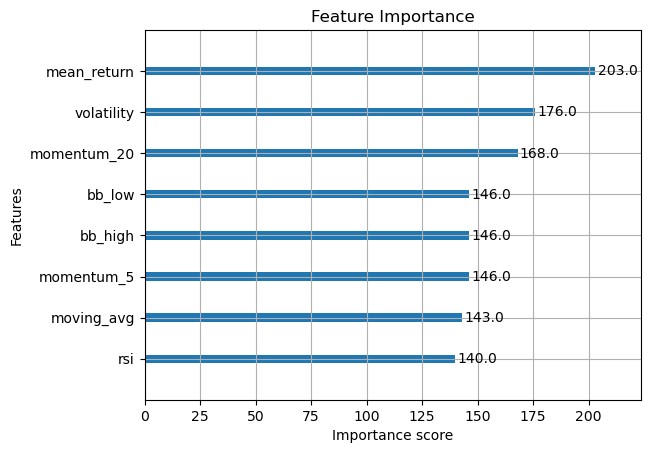

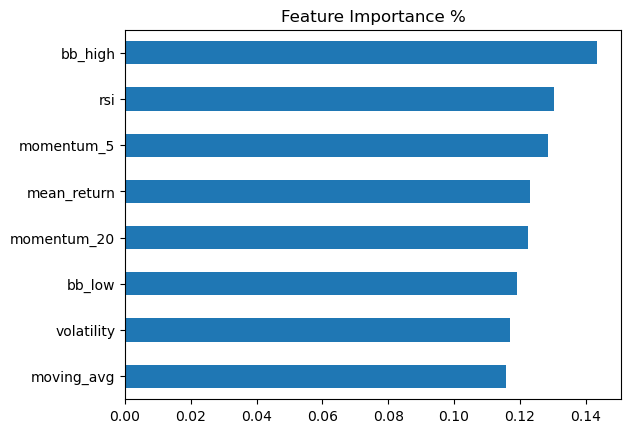

In [31]:
import xgboost as xgb

xgb.plot_importance(best_model)

plt.title("Feature Importance")

plt.show()

importance = best_model.feature_importances_

feat_importance = pd.Series(importance, index=X_train.columns)

feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance %")

plt.show()

The feature importance analysis shows that mean market returns and volatility were the most influential predictors in the XGBoost model. This suggests the algorithm is identifying momentum and risk regime signals in the data. Traditional technical indicators such as Bollinger Bands and the Relative Strength Index also contributed to the predictions, although to a lesser degree. These findings align with established quantitative finance research, where momentum and volatility factors are widely used in systematic trading strategies.

In [27]:
print("baseline_accuracy:",baseline_accuracy)
print("final_accuracy:",final_accuracy)
print("Strategy Sharpe Ratio:",strategy_sharpe)
print("cumulative:",cumulative)

baseline_accuracy: 0.49333333333333335
final_accuracy: 0.5733333333333334
Strategy Sharpe Ratio: 0.32990980203564885
cumulative: Date
2025-11-24    1.000000
2025-11-25    1.020598
2025-11-26    1.021070
2025-11-28    1.035782
2025-12-01    1.035782
                ...   
2026-03-09    1.032661
2026-03-10    1.039057
2026-03-11    1.030877
2026-03-12    1.016209
2026-03-13    1.010080
Length: 75, dtype: float64


The baseline XGBoost model achieved an accuracy of 49.3%, which is close to random prediction and consistent with the difficulty of forecasting financial markets under the Efficient Market Hypothesis. After hyperparameter optimisation using Optuna, model accuracy improved to 57.3%, demonstrating that parameter tuning can meaningfully improve predictive performance.

When applied to a simple trading strategy, the model generated a Sharpe ratio of 0.33. Although modest, this indicates the presence of a weak predictive signal. In professional quantitative finance workflows, such signals are typically combined with additional models and features to construct diversified trading strategies.